# 03 Modeling: Parkinson’s Disease Classification from Voice Biomarkers

This notebook builds machine learning models to evaluate whether biomedical voice measurements can classify Parkinson’s disease status.

The target variable is:

- `status = 0`: Healthy
- `status = 1`: Parkinson’s disease

Because the dataset contains multiple voice recordings from the same patients, this notebook uses **patient-aware splitting**. This prevents recordings from the same patient appearing in both training and testing data, which would create data leakage and overly optimistic performance.

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
figures_dir = "../reports/figures/modeling"
os.makedirs(figures_dir, exist_ok=True)

In [2]:
data_path = "../data/processed/parkinsons_cleaned.csv"

df = pd.read_csv(data_path)

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,patient_id
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,S01
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,S01
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,S01
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,S01
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,S01


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique patient IDs:", df["patient_id"].nunique())

df[["name", "patient_id", "status"]].head()

Rows: 195
Columns: 25
Unique patient IDs: 32


,name,patient_id,status
0,phon_R01_S01_1,S01,1
1,phon_R01_S01_2,S01,1
2,phon_R01_S01_3,S01,1
3,phon_R01_S01_4,S01,1
4,phon_R01_S01_5,S01,1


## Define Features and Target

The model will use the biomedical voice measurements as predictors. The `name` and `patient_id` columns are not used as model features because they are identifiers.

The target variable is `status`.

In [4]:
frequency_features = [
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)"
]

jitter_features = [
    "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)",
    "MDVP:RAP",
    "MDVP:PPQ",
    "Jitter:DDP"
]

shimmer_features = [
    "MDVP:Shimmer",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "MDVP:APQ",
    "Shimmer:DDA"
]

noise_features = [
    "NHR",
    "HNR"
]

nonlinear_features = [
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE"
]

all_feature_columns = (
    frequency_features +
    jitter_features +
    shimmer_features +
    noise_features +
    nonlinear_features
)

target = "status"
groups = df["patient_id"]

X = df[all_feature_columns]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (195, 22)
Target shape: (195,)


In [5]:
class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index().mul(100).round(2)

class_distribution = pd.DataFrame({
    "Class": ["Healthy", "Parkinson's"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

class_distribution

,Class,Count,Percentage
0,Healthy,48,24.62
1,Parkinson's,147,75.38


## Patient-Aware Train/Test Split

A standard random train/test split would be inappropriate because the dataset contains multiple recordings from the same patients. If recordings from one patient appear in both training and testing sets, the model may learn speaker-specific patterns rather than Parkinson’s-related vocal biomarkers.

To avoid this, `GroupShuffleSplit` is used with `patient_id` as the grouping variable.

In [6]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(group_split.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training recordings:", X_train.shape[0])
print("Testing recordings:", X_test.shape[0])

print("Training patients:", groups_train.nunique())
print("Testing patients:", groups_test.nunique())

Training recordings: 146
Testing recordings: 49
Training patients: 24
Testing patients: 8


In [7]:
train_patients = set(groups_train)
test_patients = set(groups_test)

overlap = train_patients.intersection(test_patients)

print("Number of overlapping patients:", len(overlap))
print("Overlapping patient IDs:", overlap)

Number of overlapping patients: 0
Overlapping patient IDs: set()


In [8]:
train_distribution = pd.DataFrame({
    "Train Count": y_train.value_counts().sort_index(),
    "Train Percentage": y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
})

test_distribution = pd.DataFrame({
    "Test Count": y_test.value_counts().sort_index(),
    "Test Percentage": y_test.value_counts(normalize=True).sort_index().mul(100).round(2)
})

train_test_distribution = pd.concat([train_distribution, test_distribution], axis=1)

train_test_distribution.index = ["Healthy", "Parkinson's"]

train_test_distribution

,Train Count,Train Percentage,Test Count,Test Percentage
Healthy,36,24.66,12,24.49
Parkinson's,110,75.34,37,75.51


## Evaluation Metrics

Because the dataset is moderately imbalanced, accuracy alone is not enough. The models will be evaluated using:

- **Accuracy**: overall proportion of correct predictions
- **Balanced accuracy**: average recall across both classes
- **Precision**: how often predicted Parkinson’s cases are correct
- **Recall**: how many actual Parkinson’s cases are detected
- **F1-score**: balance between precision and recall
- **ROC-AUC**: ranking quality across thresholds
- **Average precision / PR-AUC**: precision-recall performance, useful for imbalanced data

The confusion matrix will also be used to inspect false positives and false negatives.

In [9]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    """
    Fit a model, generate predictions, calculate performance metrics,
    and return results in a dictionary.
    """
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    }
    
    if y_score is not None:
        results["ROC-AUC"] = roc_auc_score(y_test, y_score)
        results["PR-AUC"] = average_precision_score(y_test, y_score)
    else:
        results["ROC-AUC"] = np.nan
        results["PR-AUC"] = np.nan
    
    print(f"===== {model_name} =====")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Healthy", "Parkinson's"],
        zero_division=0
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson's"]
    )
    
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    return results, model

## Baseline Model

The baseline model predicts the most frequent class. This gives a simple reference point. Any useful machine learning model should perform meaningfully better than this baseline, especially on balanced accuracy, recall, F1-score, and ROC-AUC.

===== Dummy Baseline =====
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        12
 Parkinson's       0.76      1.00      0.86        37

    accuracy                           0.76        49
   macro avg       0.38      0.50      0.43        49
weighted avg       0.57      0.76      0.65        49



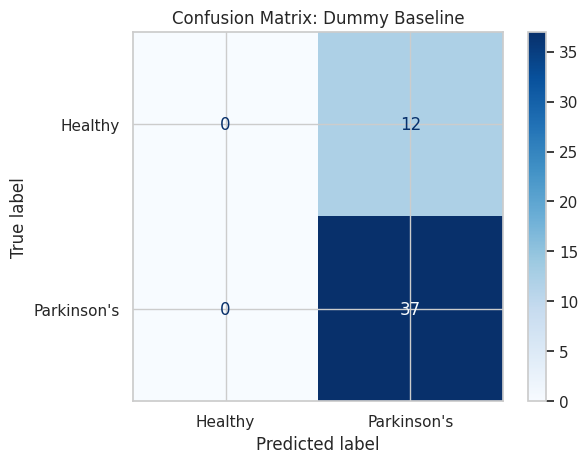

{'Model': 'Dummy Baseline',
 'Accuracy': 0.7551020408163265,
 'Balanced Accuracy': 0.5,
 'Precision': 0.7551020408163265,
 'Recall': 1.0,
 'F1': 0.8604651162790697,
 'ROC-AUC': 0.5,
 'PR-AUC': 0.7551020408163265}

In [10]:
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_results, fitted_baseline = evaluate_model(
    "Dummy Baseline",
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)

baseline_results

## Model Training

This section compares several classification models:

1. Logistic Regression
2. Support Vector Machine
3. Random Forest
4. Gradient Boosting

Logistic Regression and SVM use feature scaling because they are sensitive to feature magnitude. Random Forest and Gradient Boosting do not require scaling.

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

===== Logistic Regression =====
              precision    recall  f1-score   support

     Healthy       0.18      0.17      0.17        12
 Parkinson's       0.74      0.76      0.75        37

    accuracy                           0.61        49
   macro avg       0.46      0.46      0.46        49
weighted avg       0.60      0.61      0.61        49



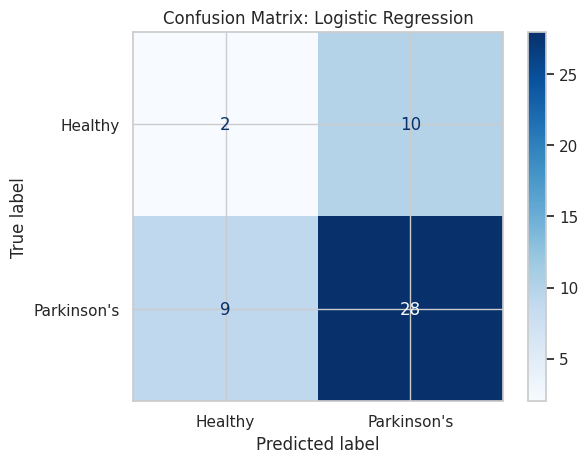

===== SVM =====
              precision    recall  f1-score   support

     Healthy       0.09      0.08      0.09        12
 Parkinson's       0.71      0.73      0.72        37

    accuracy                           0.57        49
   macro avg       0.40      0.41      0.40        49
weighted avg       0.56      0.57      0.56        49



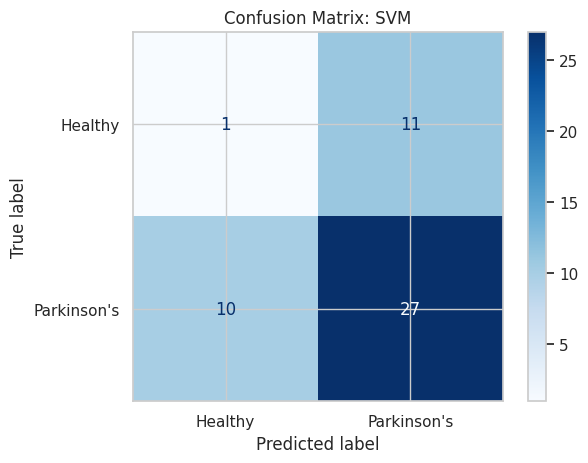

===== Random Forest =====
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        12
 Parkinson's       0.76      1.00      0.86        37

    accuracy                           0.76        49
   macro avg       0.38      0.50      0.43        49
weighted avg       0.57      0.76      0.65        49



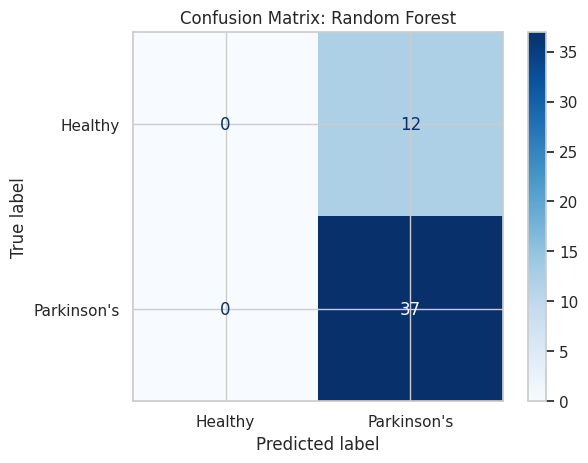

===== Gradient Boosting =====
              precision    recall  f1-score   support

     Healthy       1.00      0.08      0.15        12
 Parkinson's       0.77      1.00      0.87        37

    accuracy                           0.78        49
   macro avg       0.89      0.54      0.51        49
weighted avg       0.83      0.78      0.70        49



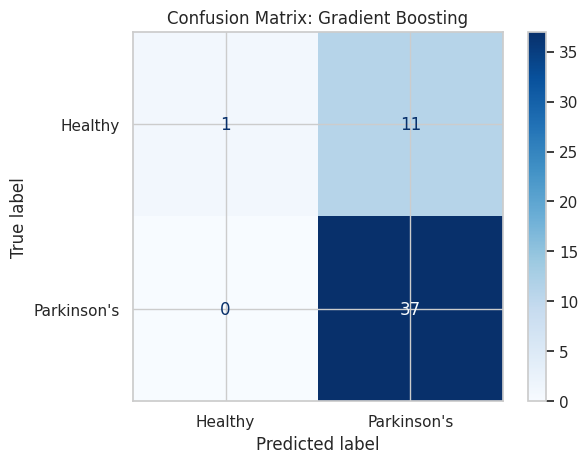

In [12]:
model_results = []
fitted_models = {}

for model_name, model in models.items():
    results, fitted_model = evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )
    
    model_results.append(results)
    fitted_models[model_name] = fitted_model

In [13]:
model_comparison = pd.DataFrame(model_results)

model_comparison = model_comparison.sort_values(
    by="Balanced Accuracy",
    ascending=False
)

model_comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Gradient Boosting,0.775510,0.541667,0.770833,1.000000,0.870588,0.738739,0.911145
2,Random Forest,0.755102,0.500000,0.755102,1.000000,0.860465,0.690315,0.901459
0,Logistic Regression,0.612245,0.461712,0.736842,0.756757,0.746667,0.614865,0.880090
1,SVM,0.571429,0.406532,0.710526,0.729730,0.720000,0.495495,0.792122


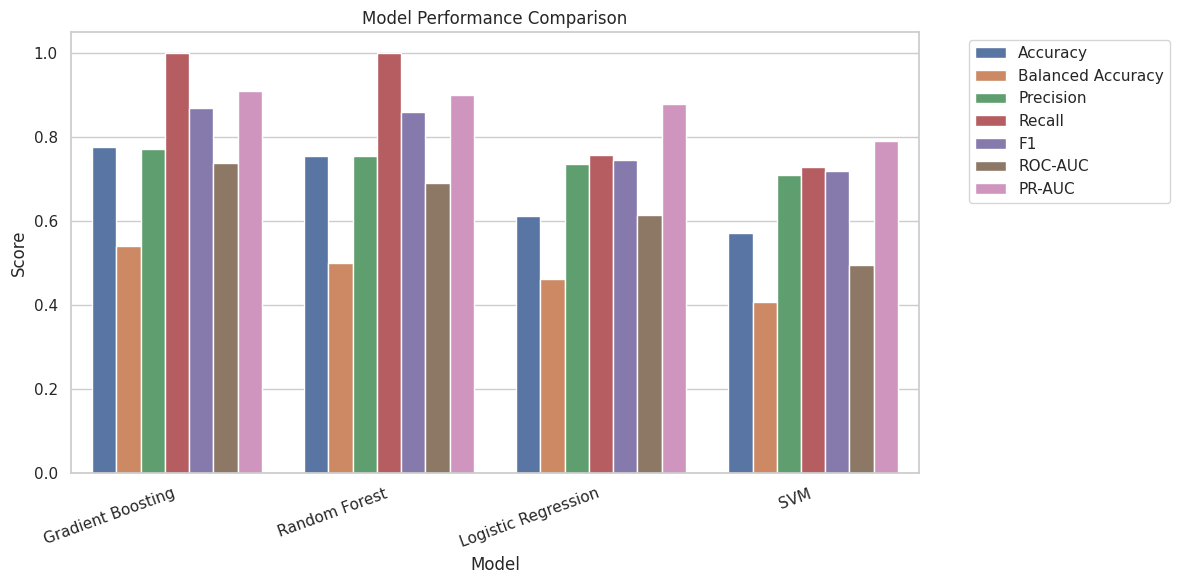

In [20]:
metrics_to_plot = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

comparison_long = model_comparison.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{figures_dir}/model_performance_comparison.png", dpi=300)
plt.show()

### Initial Model Comparison Analysis

The initial model comparison shows that Gradient Boosting performs best overall across most reported metrics, with the highest accuracy (`0.776`), highest balanced accuracy (`0.542`), highest precision (`0.771`), highest F1-score (`0.871`), highest ROC-AUC (`0.739`), and highest PR-AUC (`0.911`). Random Forest has similar accuracy (`0.755`) and also reaches perfect recall for Parkinson’s cases (`1.000`), but its balanced accuracy is only `0.500`, which indicates that it is not distinguishing the healthy class and is essentially behaving like a majority-class predictor. Gradient Boosting also has perfect Parkinson’s recall (`1.000`), meaning it correctly identifies all Parkinson’s recordings in the test set, but its confusion matrix shows that it still misclassifies most healthy recordings as Parkinson’s. Logistic Regression performs worse in accuracy (`0.612`) but is less extreme than Random Forest because it predicts some healthy cases correctly. SVM has the weakest overall performance, with the lowest accuracy (`0.571`), balanced accuracy (`0.407`), ROC-AUC (`0.495`), and PR-AUC (`0.792`). Overall, the models are strongly affected by the class imbalance: Random Forest and Gradient Boosting favor the majority Parkinson’s class, producing high Parkinson’s recall but poor healthy-class detection. Compared with a dummy majority-class baseline, which would predict Parkinson’s for every sample and achieve about `0.755` accuracy with `0.500` balanced accuracy on this test set, only Gradient Boosting shows a small improvement in accuracy and balanced accuracy. These results suggest that the initial models are learning some useful signal, but performance is not yet strong enough to claim reliable classification, especially for the minority healthy class.


## Patient-Aware Cross-Validation

The initial train/test split gives one estimate of model performance, but results can depend on which patients are assigned to the test set.

To get a more reliable estimate, this section uses `GroupKFold` cross-validation. This ensures that all recordings from the same patient stay within the same fold.

In [15]:
group_kfold = GroupKFold(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [16]:
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=group_kfold,
        scoring=scoring,
        return_train_score=False
    )
    
    result = {
        "Model": model_name
    }
    
    for metric in scoring.keys():
        result[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_std"] = scores[f"test_{metric}"].std()
    
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,Logistic Regression,0.708623,0.093661,0.634758,0.153140,0.842581,0.087756,0.769516,0.148435,0.793769,0.082165,0.720806,0.154927,0.901869,0.070325
1,SVM,0.650193,0.133704,0.586084,0.141471,0.805499,0.125736,0.716613,0.222676,0.735960,0.144080,0.736371,0.133600,0.902206,0.072388
2,Random Forest,0.759202,0.091999,0.616864,0.162053,0.813012,0.115593,0.894839,0.113914,0.842771,0.074948,0.814519,0.171199,0.942241,0.063625
3,Gradient Boosting,0.765251,0.109837,0.637590,0.164765,0.818767,0.117664,0.886290,0.112041,0.843597,0.088667,0.778351,0.185653,0.911294,0.081576


In [17]:
cv_summary = cv_results_df[[
    "Model",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "roc_auc_mean",
    "average_precision_mean"
]].copy()

cv_summary = cv_summary.sort_values(
    "balanced_accuracy_mean",
    ascending=False
)

cv_summary

,Model,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,average_precision_mean
3,Gradient Boosting,0.765251,0.637590,0.818767,0.886290,0.843597,0.778351,0.911294
0,Logistic Regression,0.708623,0.634758,0.842581,0.769516,0.793769,0.720806,0.901869
2,Random Forest,0.759202,0.616864,0.813012,0.894839,0.842771,0.814519,0.942241
1,SVM,0.650193,0.586084,0.805499,0.716613,0.735960,0.736371,0.902206


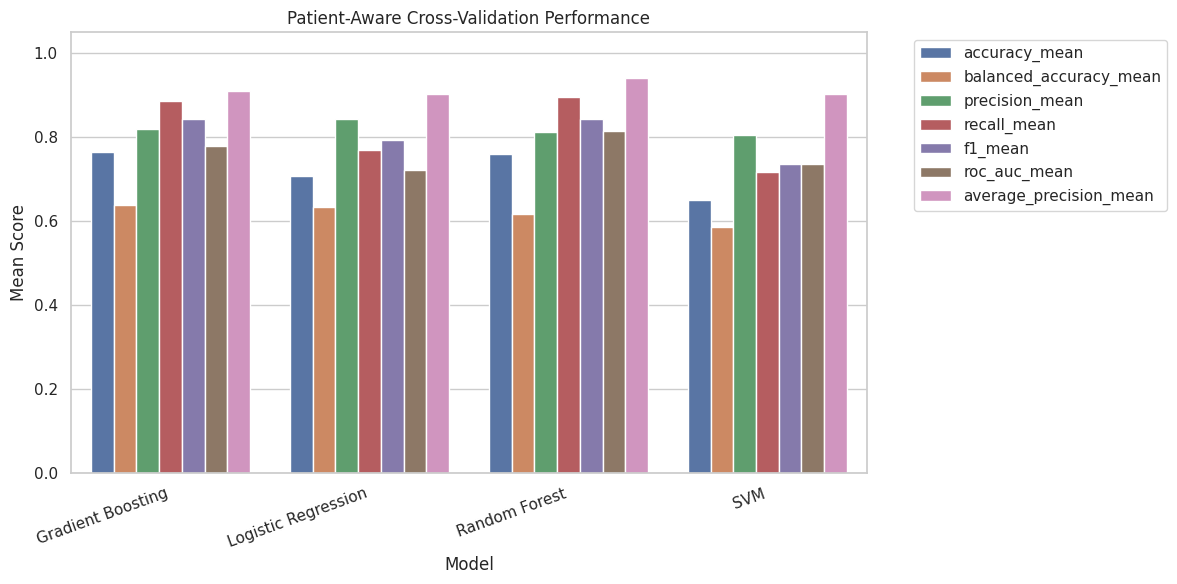

In [49]:
cv_plot = cv_summary.melt(
    id_vars="Model",
    value_vars=[
        "accuracy_mean",
        "balanced_accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "roc_auc_mean",
        "average_precision_mean"
    ],
    var_name="Metric",
    value_name="Mean Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=cv_plot,
    x="Model",
    y="Mean Score",
    hue="Metric"
)

plt.title("Patient-Aware Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{figures_dir}/patient-aware_cross_validation_performance.png", dpi=300)
plt.show()

### Patient-Aware Cross-Validation Analysis

The patient-aware cross-validation results provide a more trustworthy estimate of model performance because each fold evaluates the model on patients that were not seen during training. Across the grouped folds, Gradient Boosting performs best overall by a narrow margin, with the highest mean accuracy (`0.765`), highest balanced accuracy (`0.638`), and highest mean F1-score (`0.844`). Random Forest performs very similarly, with nearly the same accuracy (`0.759`) and F1-score (`0.843`), the highest Parkinson’s recall (`0.895`), the highest ROC-AUC (`0.815`), and the highest average precision (`0.942`). Logistic Regression has slightly lower accuracy (`0.709`) but remains competitive in balanced accuracy (`0.635`) and has the highest precision (`0.843`), suggesting that it may be more conservative when predicting Parkinson’s disease. SVM performs the weakest overall, with the lowest mean accuracy (`0.650`), balanced accuracy (`0.586`), recall (`0.717`), and F1-score (`0.736`).

These results are generally consistent with the single train/test split in showing Gradient Boosting and Random Forest as the strongest models, but the grouped cross-validation gives a more stable and realistic view across multiple patient-based folds. The balanced accuracy values are noticeably lower than the raw accuracy values for every model, showing that class imbalance remains an important issue and that the models perform better on the majority Parkinson’s class than on the minority healthy class. The standard deviations are also fairly large across several metrics, which is expected because the dataset contains a small number of extracted patients and each fold may contain a different mix of healthy and Parkinson’s subjects. Compared with regular row-based splitting, grouped cross-validation is more appropriate for this dataset because it prevents recordings from the same patient from appearing in both training and validation sets. This reduces data leakage and gives a better estimate of whether the models can generalize to unseen patients rather than simply recognizing subject-specific voice patterns.


## ROC and Precision-Recall Curves

This section visualizes classification performance across decision thresholds.

The ROC curve shows the tradeoff between true positive rate and false positive rate. The precision-recall curve is especially useful when classes are imbalanced.

In [23]:
best_model_name = cv_summary.iloc[0]["Model"]

best_model_name

'Gradient Boosting'

In [24]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

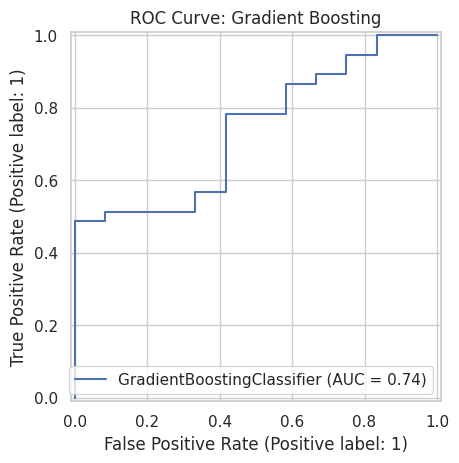

In [25]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(f"ROC Curve: {best_model_name}")
plt.savefig(f"{figures_dir}/ROC_curve_gradient_boost.png", dpi=300)
plt.show()

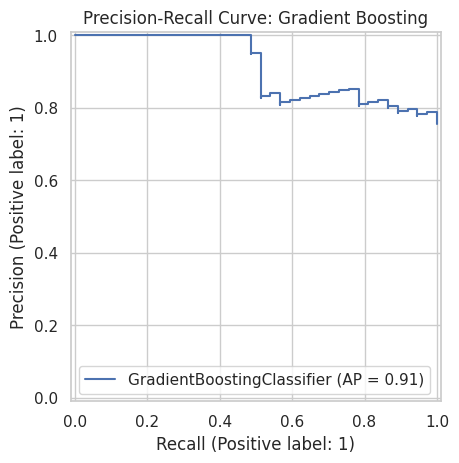

In [26]:
PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(f"Precision-Recall Curve: {best_model_name}")
plt.savefig(f"{figures_dir}/precision-recall_curve_gradient_boosting.png", dpi=300)
plt.show()

### ROC and Precision-Recall Curve Analysis

The ROC curve for the selected Gradient Boosting model shows moderate class separation, with an AUC of approximately 0.74. This suggests that the model is performing better than random chance at ranking Parkinson’s and healthy cases, but the curve is not strong enough to indicate highly reliable separation between the two groups. The precision-recall curve shows stronger performance for the positive Parkinson’s class, with an average precision of approximately 0.91. This is consistent with the earlier classification results showing high recall for Parkinson’s cases and relatively strong precision when predicting the positive class. However, because Parkinson’s recordings make up the majority of the dataset, precision-recall performance should be interpreted carefully; high performance on the positive class does not necessarily mean the model handles the minority healthy class well. The confusion matrix results showed that several healthy cases were still misclassified as Parkinson’s, so the model may be better at detecting Parkinson’s cases than at correctly identifying healthy controls. Overall, these curves suggest that the vocal biomarker features contain useful predictive signal, but the results should be treated as exploratory because the dataset contains a small number of patients and repeated recordings. Patient-aware validation remains essential for estimating whether the model can generalize to unseen individuals.

## Threshold Tuning

Most classifiers use a default threshold of `0.50` for converting predicted probabilities into class predictions. However, in healthcare screening contexts, different thresholds may be considered depending on whether the goal is to reduce false negatives or reduce false positives.

This section evaluates how precision, recall, and F1-score change across different probability thresholds.

In [28]:
if hasattr(best_model, "predict_proba"):
    y_test_scores = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    raw_scores = best_model.decision_function(X_test)
    y_test_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
else:
    raise ValueError("Selected model does not provide probability scores or decision scores.")

In [29]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_test_scores >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1,Balanced Accuracy
0,0.10,0.755102,1.000000,0.860465,0.500000
1,0.15,0.770833,1.000000,0.870588,0.541667
2,0.20,0.770833,1.000000,0.870588,0.541667
3,0.25,0.770833,1.000000,0.870588,0.541667
4,0.30,0.770833,1.000000,0.870588,0.541667
5,0.35,0.770833,1.000000,0.870588,0.541667
6,0.40,0.770833,1.000000,0.870588,0.541667
7,0.45,0.770833,1.000000,0.870588,0.541667
8,0.50,0.770833,1.000000,0.870588,0.541667
9,0.55,0.770833,1.000000,0.870588,0.541667


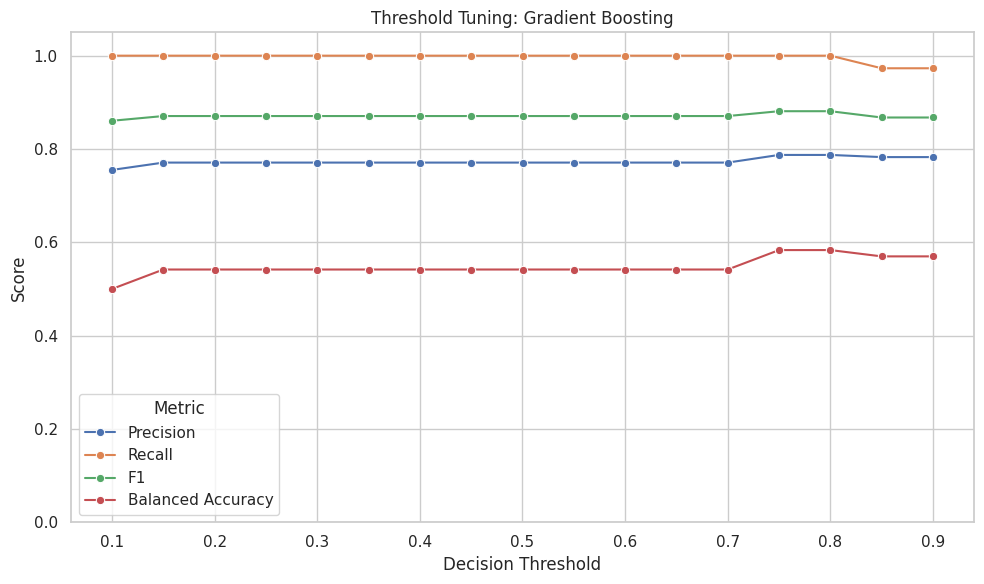

In [31]:
threshold_long = threshold_df.melt(
    id_vars="Threshold",
    value_vars=["Precision", "Recall", "F1", "Balanced Accuracy"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=threshold_long,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o"
)

plt.title(f"Threshold Tuning: {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{figures_dir}/threshold_tuning_gradient_boosting.png", dpi=300)
plt.show()

In [32]:
best_threshold_row = threshold_df.sort_values("F1", ascending=False).iloc[0]

best_threshold_row

Threshold            0.750000
Precision            0.787234
Recall               1.000000
F1                   0.880952
Balanced Accuracy    0.583333
Name: 13, dtype: float64

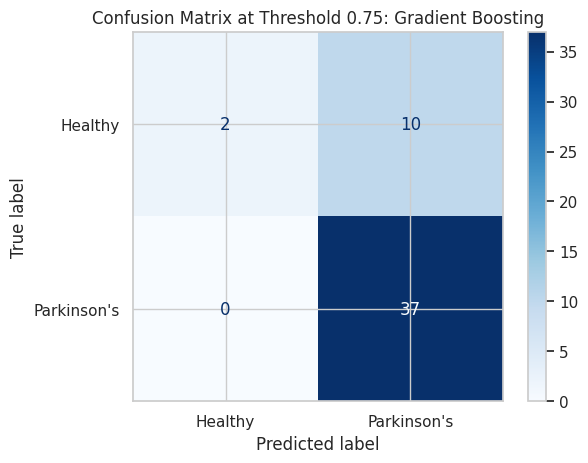

              precision    recall  f1-score   support

     Healthy       1.00      0.17      0.29        12
 Parkinson's       0.79      1.00      0.88        37

    accuracy                           0.80        49
   macro avg       0.89      0.58      0.58        49
weighted avg       0.84      0.80      0.74        49



In [34]:
best_threshold = best_threshold_row["Threshold"]

y_pred_best_threshold = (y_test_scores >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Parkinson's"]
)

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {best_threshold:.2f}: {best_model_name}")
plt.savefig(f"{figures_dir}/confusion_matrix_0.75_gradient_boosting.png", dpi=300)
plt.show()

print(classification_report(
    y_test,
    y_pred_best_threshold,
    target_names=["Healthy", "Parkinson's"],
    zero_division=0
))

### Threshold Tuning Analysis

The threshold tuning results show that the best F1-score occurs at thresholds of 0.75 and 0.80, where the Gradient Boosting model reaches an F1-score of approximately 0.881. At these thresholds, Parkinson’s recall remains perfect (1.000), meaning all Parkinson’s cases in the test set are still correctly identified, while precision improves slightly to approximately 0.787. Balanced accuracy also improves from 0.542 at the default 0.50 threshold to 0.583 at the selected 0.75 threshold. This improvement occurs because the higher threshold correctly identifies slightly more healthy cases while still preserving full recall for Parkinson’s cases. In contrast, very low thresholds over-favor the Parkinson’s class and produce weaker balanced accuracy because most healthy cases are misclassified.

For a screening-oriented model, a threshold such as 0.75 would make the most sense in this experiment because it maintains perfect Parkinson’s recall while modestly improving precision and healthy-class detection. However, this threshold should not be interpreted as a clinical decision threshold. It was selected using a small exploratory dataset with repeated recordings and a limited number of patients, so it may not generalize to new populations or real clinical settings. Instead, the threshold tuning results should be viewed as an exploratory demonstration of how changing the decision threshold can adjust the tradeoff between recall, precision, and balanced accuracy.

## Model Interpretability

This section examines which vocal biomarkers contribute most to the model. The interpretation method depends on the model type.

For Logistic Regression, standardized coefficients can show which biomarkers push predictions toward Parkinson’s or healthy classification.

For tree-based models, feature importance can show which variables are most useful for splitting the data, although these importances should be interpreted cautiously when features are highly correlated.

In [35]:
interpretable_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

interpretable_model.fit(X_train, y_train)

log_reg_coefficients = interpretable_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": all_feature_columns,
    "Coefficient": log_reg_coefficients,
    "Absolute Coefficient": np.abs(log_reg_coefficients)
}).sort_values("Absolute Coefficient", ascending=False)

coef_df

,Feature,Coefficient,Absolute Coefficient
16,RPDE,1.429438,1.429438
12,MDVP:APQ,1.306781,1.306781
20,D2,1.012651,1.012651
19,spread2,1.003628,1.003628
14,NHR,-0.720193,0.720193
0,MDVP:Fo(Hz),-0.712252,0.712252
21,PPE,0.645917,0.645917
18,spread1,0.640148,0.640148
17,DFA,0.353156,0.353156
2,MDVP:Flo(Hz),0.339105,0.339105


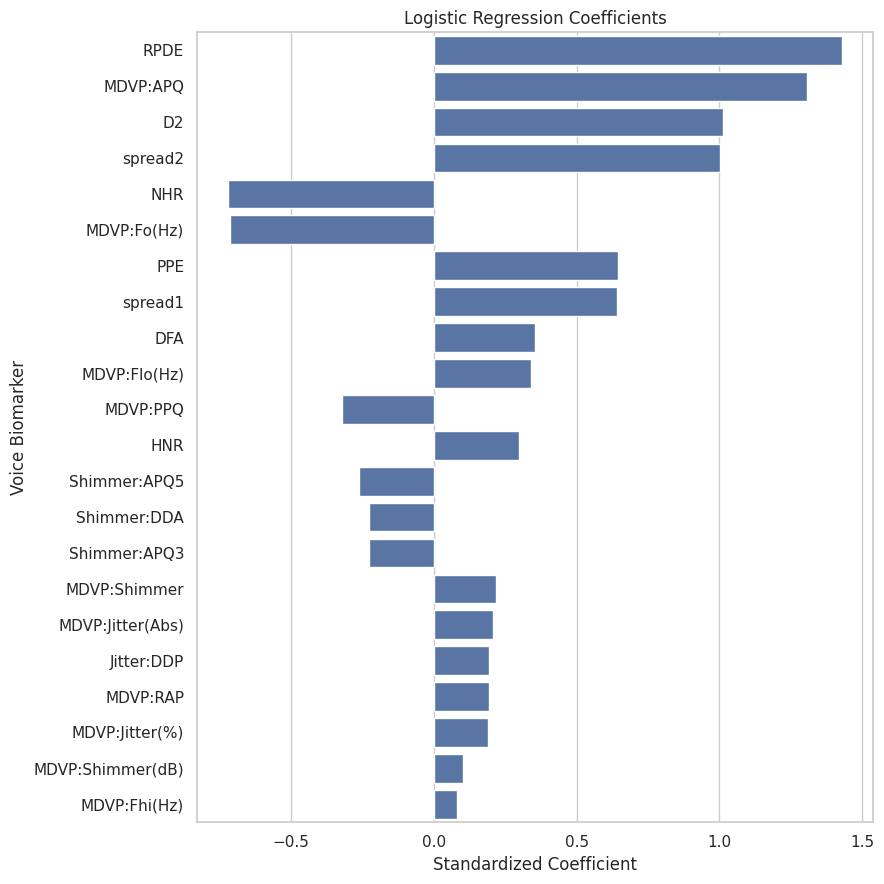

In [37]:
plt.figure(figsize=(9, 9))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Voice Biomarker")

plt.tight_layout()
plt.savefig(f"{figures_dir}/logistic_regression_coefficients.png", dpi=300)
plt.show()

In [38]:
rf_model = fitted_models.get("Random Forest")

if rf_model is None:
    rf_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )
    rf_model.fit(X_train, y_train)

rf_importance_df = pd.DataFrame({
    "Feature": all_feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance_df

,Feature,Importance
21,PPE,0.145617
18,spread1,0.129572
19,spread2,0.113429
0,MDVP:Fo(Hz),0.090897
16,RPDE,0.073655
12,MDVP:APQ,0.057197
1,MDVP:Fhi(Hz),0.044899
4,MDVP:Jitter(Abs),0.041836
3,MDVP:Jitter(%),0.041766
2,MDVP:Flo(Hz),0.035352


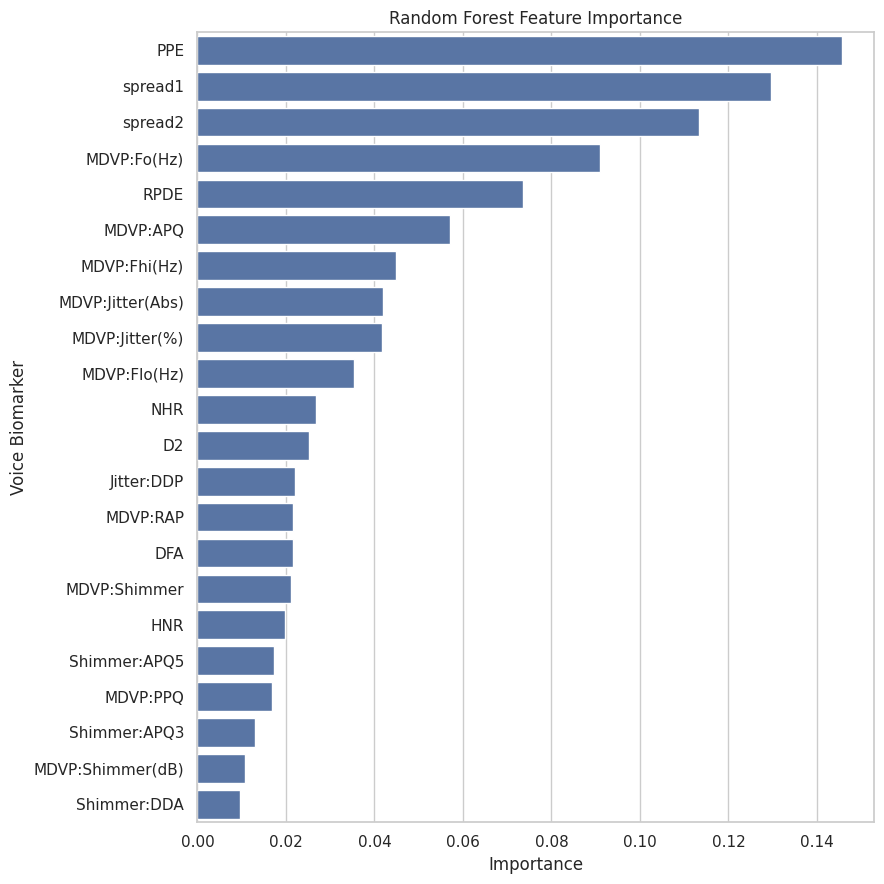

In [40]:
plt.figure(figsize=(9, 9))

sns.barplot(
    data=rf_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Voice Biomarker")

plt.tight_layout()
plt.savefig(f"{figures_dir}/random_forest_feature_importance.png", dpi=300)
plt.show()

In [41]:
top_logistic_features = coef_df.head(10)["Feature"].tolist()
top_rf_features = rf_importance_df.head(10)["Feature"].tolist()

feature_comparison = pd.DataFrame({
    "Top Logistic Regression Features": pd.Series(top_logistic_features),
    "Top Random Forest Features": pd.Series(top_rf_features)
})

feature_comparison

,Top Logistic Regression Features,Top Random Forest Features
0,RPDE,PPE
1,MDVP:APQ,spread1
2,D2,spread2
3,spread2,MDVP:Fo(Hz)
4,NHR,RPDE
5,MDVP:Fo(Hz),MDVP:APQ
6,PPE,MDVP:Fhi(Hz)
7,spread1,MDVP:Jitter(Abs)
8,DFA,MDVP:Jitter(%)
9,MDVP:Flo(Hz),MDVP:Flo(Hz)


### Feature Importance Interpretation

The feature importance results show that both models rely on biomarkers that were identified as important during the exploratory analysis, but they rank them differently. In Logistic Regression, the largest standardized coefficients are observed for RPDE, MDVP:APQ, D2, spread2, NHR, and MDVP:Fo(Hz). Positive coefficients indicate features that increase the model’s probability of predicting Parkinson’s disease, while negative coefficients indicate features that decrease that probability after scaling and accounting for the other variables in the model. Several nonlinear features, including RPDE, D2, spread2, PPE, and spread1, appear among the more influential Logistic Regression predictors, along with traditional measures such as MDVP:APQ, NHR, and MDVP:Fo(Hz).

The Random Forest feature importance results align even more closely with the strongest EDA findings. Its top three features are PPE, spread1, and spread2, which were also the strongest features in the patient-level effect size, correlation, and violin plot analyses. Additional important Random Forest predictors include MDVP:Fo(Hz), RPDE, MDVP:APQ, MDVP:Fhi(Hz), MDVP:Jitter(Abs), MDVP:Jitter(%), and MDVP:Flo(Hz). This suggests that the model is using a mixture of nonlinear biomarkers, frequency measures, and jitter/shimmer-related measurements to classify Parkinson’s status.

Overall, the most promising biomarkers appear to be the nonlinear features PPE, spread1, spread2, and RPDE, along with selected traditional voice features such as MDVP:Fo(Hz), MDVP:Flo(Hz), MDVP:APQ, and jitter measures. However, the interpretation of individual feature importance should be cautious because many jitter and shimmer variables are highly correlated with one another. When features contain overlapping information, model importance can be split across related predictors or shifted toward one variable within a correlated group. Therefore, these results should be interpreted as evidence that groups of related vocal biomarkers are useful, rather than as definitive proof that one individual feature is uniquely responsible for classification performance.

## Feature Group Comparison

This section compares model performance using different groups of biomarkers.

The goal is to evaluate whether Parkinson’s classification is driven more strongly by frequency, jitter, shimmer, noise, nonlinear features, or the full feature set.

In [42]:
feature_group_experiments = {
    "Frequency Only": frequency_features,
    "Jitter Only": jitter_features,
    "Shimmer Only": shimmer_features,
    "Noise Only": noise_features,
    "Nonlinear Only": nonlinear_features,
    "Full Feature Set": all_feature_columns
}

In [43]:
feature_group_results = []

for group_name, feature_list in feature_group_experiments.items():
    X_group = df[feature_list]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    scores = cross_validate(
        model,
        X_group,
        y,
        groups=groups,
        cv=group_kfold,
        scoring=scoring,
        return_train_score=False
    )
    
    feature_group_results.append({
        "Feature Group": group_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_average_precision"].mean()
    })

feature_group_results_df = pd.DataFrame(feature_group_results)

feature_group_results_df.sort_values("Balanced Accuracy", ascending=False)

,Feature Group,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Shimmer Only,0.711454,0.730511,0.942883,0.677688,0.761784,0.774459,0.935079
4,Nonlinear Only,0.724196,0.680591,0.868095,0.761183,0.799860,0.799737,0.922652
3,Noise Only,0.689833,0.680000,0.890000,0.693333,0.766277,0.616075,0.875182
5,Full Feature Set,0.708623,0.634758,0.842581,0.769516,0.793769,0.720806,0.901869
1,Jitter Only,0.636422,0.629919,0.885227,0.626505,0.706129,0.733937,0.926013
0,Frequency Only,0.631660,0.562930,0.816467,0.692527,0.739832,0.635526,0.843874


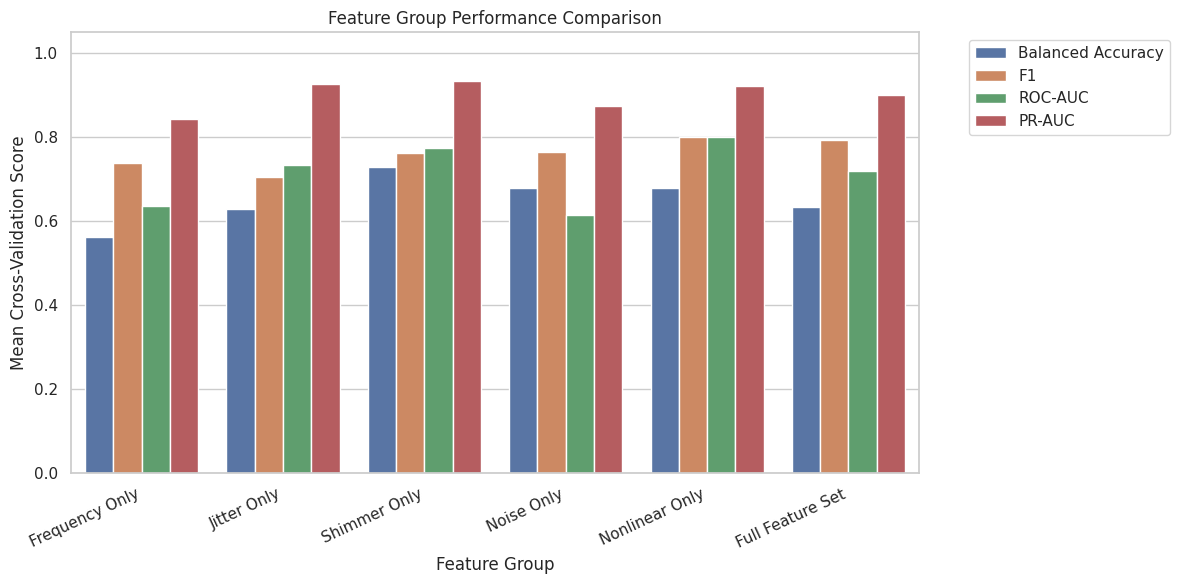

In [45]:
feature_group_plot = feature_group_results_df.melt(
    id_vars="Feature Group",
    value_vars=["Balanced Accuracy", "F1", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_group_plot,
    x="Feature Group",
    y="Score",
    hue="Metric"
)

plt.title("Feature Group Performance Comparison")
plt.xlabel("Feature Group")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{figures_dir}/feature_group_performance_comparison.png", dpi=300)
plt.show()

### Feature Group Comparison Analysis

The feature group comparison shows that several biomarker groups contain useful predictive information on their own, but performance varies depending on the metric. The Shimmer Only group performs best by balanced accuracy (0.731) and PR-AUC (0.935), suggesting that amplitude instability features are especially useful for distinguishing the two classes in patient-aware cross-validation. The Nonlinear Only group has the highest accuracy (0.724), F1-score (0.800), and ROC-AUC (0.800), which supports the earlier EDA finding that nonlinear biomarkers such as spread1, PPE, and spread2 show strong group-level differences. The Noise Only group also performs reasonably well by balanced accuracy (0.680), although its ROC-AUC is lower, suggesting less consistent ranking ability across decision thresholds. Jitter features perform better than frequency features overall, while the Frequency Only group is the weakest by balanced accuracy and PR-AUC.

Interestingly, the full feature set does not outperform the best individual feature groups in this comparison. Its balanced accuracy (0.635), ROC-AUC (0.721), and PR-AUC (0.902) are lower than the best shimmer-only and nonlinear-only results. This may reflect the small dataset size, high correlation among related biomarkers, and possible redundancy or noise introduced when all variables are included together. Overall, these results support the exploratory findings: shimmer features and nonlinear biomarkers appear especially informative, while frequency, jitter, and noise features still provide useful but less consistent signal. For later modeling, feature selection or regularization may help combine the strongest biomarker groups without adding unnecessary redundant predictors.

In [46]:
models_dir = "../models"
reports_dir = "../reports/modeling"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)

In [47]:
final_model = best_model
final_model_name = best_model_name

model_path = os.path.join(models_dir, "parkinsons_voice_model.pkl")

joblib.dump(final_model, model_path)

model_path

'../models/parkinsons_voice_model.pkl'

In [48]:
model_comparison.to_csv(
    os.path.join(reports_dir, "train_test_model_comparison.csv"),
    index=False
)

cv_summary.to_csv(
    os.path.join(reports_dir, "grouped_cv_model_comparison.csv"),
    index=False
)

feature_group_results_df.to_csv(
    os.path.join(reports_dir, "feature_group_comparison.csv"),
    index=False
)

coef_df.to_csv(
    os.path.join(reports_dir, "logistic_regression_coefficients.csv"),
    index=False
)

rf_importance_df.to_csv(
    os.path.join(reports_dir, "random_forest_feature_importance.csv"),
    index=False
)